# Funksjoner og plotting i Python

Av Sigurd Rage, Universitetet i Sørøst-Norge

# ToDo
* Lage flere oppgaver til hvert kodeeksempel
* Dele opp denne siden pr tema, kan ha egen side om plotting feks?
* Se litt på didaktiske vinkler
* Utvide seksjonen om funksjoner til flere eksempler med forklaringer
* Funksjoner og plotting kan kobles lettere til matematikk. Lage egen side om funksjoner

# Arrayer

En array er en form for liste hvor alle elementene er av samme datatype. Et array kan være endimensjonalt, som en vanlig liste, men kan også ha flere dimensjoner. For eksempel vil en tabell kunne representeres ved hjelp av en 2-dimensjonal liste. Python har ikke denne datatypen innebygget, men slike finnes i mange standardbiblioteker vi kan benytte oss av. Et vanlig og bra bibliotek til matematikk heter numpy. Dette biblioteker inneholder også ferdigkompilerte rutiner skrevet i C som gjør at det kan gjøre beregninger med og behandle store datamengder på relativt kort tid.

Et array kan lages manuelt, og inneholde forskjellige datatyper akkurat som den innebygde typen liste i python. Men vi skal heller konsentrere oss om hvordan vi kan bruke disse til å lage funksjonstabeller og matematiske analyser

Funksjonen linspace lager en array hvor du kan bestemme start og sluttverdi, og hvor mange elementer du vil ha med i arrayet. Dette er nyttig når man for eksempel skal lage en tabell med x-verdier. Se på følgende eksempel.

In [5]:
import numpy as np

x_array = np.linspace(-2, 6, 9)
print(x_array)

[-2. -1.  0.  1.  2.  3.  4.  5.  6.]


I koden overfor har jeg bestilt 9 verdier (med hensikt!) fra -2 til 6, og fått tilbake heltallene -2, -1, 0, 1, 2, 3, 4, 5 og 6. Hvorfor gir 9 verdier meg eksakte heltall i listen?

Man kan lage slike linspaces (linear spaces) med så mange elementer du vil for bedre oppløsning under beregninger, plotting og så videre. Hvis jeg vil ha 50 x-verdier mellom -2 til 6 skriver jeg kommandoen som under. linspace()-funksjonen deler automatisk opp slik at jeg får 50 verdier jevt fordelt mellom -2 og 6.

In [1]:
import numpy as np

x_array = np.linspace(-2, 6, 50)
print(x_array)

[-2.         -1.83673469 -1.67346939 -1.51020408 -1.34693878 -1.18367347
 -1.02040816 -0.85714286 -0.69387755 -0.53061224 -0.36734694 -0.20408163
 -0.04081633  0.12244898  0.28571429  0.44897959  0.6122449   0.7755102
  0.93877551  1.10204082  1.26530612  1.42857143  1.59183673  1.75510204
  1.91836735  2.08163265  2.24489796  2.40816327  2.57142857  2.73469388
  2.89795918  3.06122449  3.2244898   3.3877551   3.55102041  3.71428571
  3.87755102  4.04081633  4.20408163  4.36734694  4.53061224  4.69387755
  4.85714286  5.02040816  5.18367347  5.34693878  5.51020408  5.67346939
  5.83673469  6.        ]


````{tip} Oppgave
Noen ganger er det hensiktsmessig å lage heltallstabeller, for eksempel hvis jeg vil lage en enkel verditabell til en funksjon. Gitt kodesnutten under, hvor jeg angir laveste verdi i tabellen som a, og høyeste verdi som b, kan dere lage et uttrykk for antall elementer i tabellen slik at tabellen alltid blir med heltall?
```{code-block} Python
:linenos:
:emphasize-lines: 5
import numpy as np

a = -2
b = 6
c = #??? kan dere lage et utrykk for c her?

x_array = np.linspace(a, b, c)
print(x_array)
```
````

````{hint} Løsningsforslag
:class:dropdown
Hvis feks $a = -2$ og $b = -6$, så er jo differansen $8$. MEN vi skal ha med tallene *fra og med* $-2$ og *til og med* $6$, så vi må legge til ett element, slik at $ c = b - a + 1 $

Prøv også å endre a og b, og se om koden alltid gir en heltallsarray

Her er løsningen:
```{code-block} Python
:linenos:
import numpy as np

a = -2
b = 6
c = b - a + 1

x_array = np.linspace(a, b, c)
print(x_array)
```
````

## Å lage en verditabell for en matematisk funksjon

Hvis jeg nå vil gjøre beregninger på x-tabellen min og lage en y-tabell gjøres det superenkelt og superraskt ved hjelp av de vanlige regneartene i python. Hvis jeg vil ha en funksjonstabell over y-verdiene til funksjonen: $ f(x) = x^2 - 4 $, så kan jeg ta utgangpunkt i løsningen over. Jeg vil undersøke funksjonsverdiene fra x = -3 til x = 4

In [9]:
import numpy as np

a = -3
b = 4
c = b - a + 1

x = np.linspace(a, b, c)
y = x**2 - 4

print("x-verdier:", x)
print("y-verdier:", f)

x-verdier: [-3. -2. -1.  0.  1.  2.  3.  4.]
y-verdier: [ 5.  0. -3. -4. -3.  0.  5. 12.]


```{tip} Oppgave
Lek deg litt med koden over, prøv å endre funksjonen i "y=" til en lineær funksjon og en annen andregradsfunksjon, og endre gjerne på start og slutt-verdi for x-tabellen!
```

# Plotting

## Enkelt plott av koordinatene i verditabellen

I forrige seksjon brukte vi print til å se på verdiene i listene og arrayene våre, og så på hvordan vi lager x- og y-tabeller for funksjoner. Det går selvfølgelig også an å plotte grafer fra disse tabellverdiene. Det finnes mange biblioteker som kan tilby dette, men vi skal konsentrere oss om funksjonen plot fra biblioteket matplotlib. Dette er et stort bibliotek med mange undergrupper – derfor skal vi ikke importere hele biblioteket, så legg merke til hvordan vi importerer her. (Mer om importmetoder lenger ned i dokumentet!)

For å lage et enkelt plot lager jeg en x og en y-tabell først, og sender disse som argumenter inn i plottefunksjonen. Her er også kode for å sette navn på aksene.

Vi kan ta utgangspunkt i eksempelet fra over, der vi lagde verditabell for funksjonen $f(x) = x^2-4$, med verditabell med heltallene fra -3 til 4

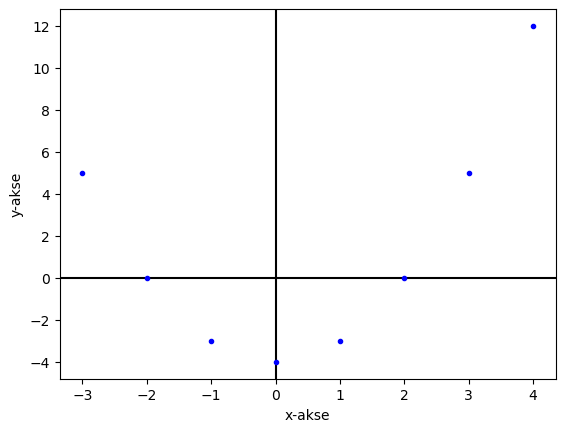

In [1]:
import numpy as np
import matplotlib.pyplot as plt # bibliotek for å plotte grafer

a = -3
b = 4
c = b - a + 1

x = np.linspace(a, b, c)
y = x**2 - 4

# Plotter y mot x og setter på aksenavn
plt.xlabel("x-akse") # setter navn på x-aksen
plt.ylabel("y-akse") # setter navn på y-aksen
plt.axvline(x=0, color="black") # tegner x-aksen i svart
plt.axhline(y=0, color="black") # Tegner y-aksen i svart
plt.plot(x,y, "b.")  # plotter verditabellene x og y med blå prikker!
                     # i et koordinatsystem (skalerere automatisk!)
plt.show()           # viser plottet til skjerm

Som dere ser over, ble resultatet ganske kantete. "plot()" funksjonen plotter kun inn punktene fra x- og y-tabellen. Datamaskinen kan faktisk egentlig ikke lage kontinuerlige grafer til oss, men hvis vi øker antallet verdier i verditabellen vår så kan vi nærme oss noe som ser kontinuerlig ut:

```{tip} Oppgave
1. Fjern tekststrengen "b." fra plot() funksjonen, så vil du se at programmet tegner en linje mellom punktene i stedet for mange kryss.
2. Bytt ut verdien til antall elementer c til 20, 50, 100 og se hva som skjer.
```

## "Kontinuerlige" plots

I dette eksempelet vil jeg plotte grafen til funksjonen
$$ f(x)=-x^3-3x^2+2x-2 $$ 
Fra x = -4 til x = 2

Nå som vi har blitt litt fortrolige med å lage x- og y-tabeller, og å plotte resultatene trenger jeg ikke lenger å begrense meg til heltallstabeller, og skriver inn start, slutt og antall elementer direkte i plottefunksjonen. Her har jeg valgt å lage verditabeller med 100 elementer, og plot()-funksjonen forbinder de 100 elementene slik at grafen ser tilnærmet kontinuerlig ut.

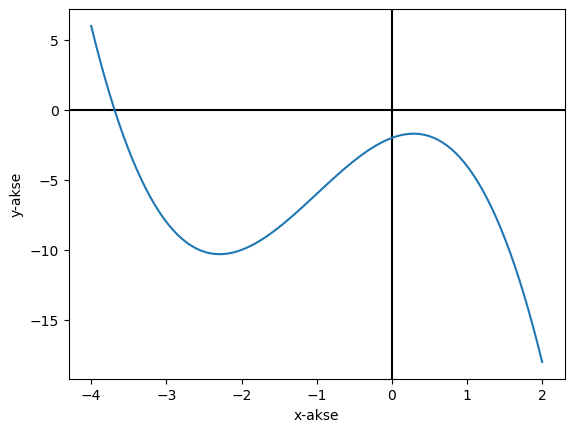

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Lager x-verditabell
x = np.linspace(-4, 2, 100)
y = -x**3-3*x**2+2*x-2

# Plotter y mot x og setter på aksenavn
plt.xlabel("x-akse")
plt.ylabel("y-akse")
plt.axvline(x=0, color="black") # tegner x-aksen i svart
plt.axhline(y=0, color="black") # Tegner y-aksen i svart
plt.plot(x,y)
plt.show()

Siden plot()-funksjonen tegner linjestykker mellom de 100 punktene mine begynner dette nå å ligne på en kontinuerlig graf (men den er IKKE det, egentlig! Men, dess flere elementer du har i verditabellen din, dess mer nøyaktig blir plottet!

# Funksjoner

Funksjoner i programmering er ikke det helt samme som funksjoner i matematikk, men de har noen likheter. I programmering er funksjoner ferdiglagede kodesnutter som skal brukes flere ganger. I denne aktiviteten skal vi kun se på hvordan du kan definere en matematisk funksjon. (IKKE FERDIG!)

## Hvordan bruke funksjoner i matematisk sammenheng

I kodene over lagde vi først en x-tabell, og så en y-tabell slik:
```{code} Pyhton
x = np.linspace(a, b, c)
y = x**2 - 4
```
Men vi kan også bruke en python-funksjon til å definere funksjonsuttrykket og da blir koden litt ryddigere(?) I kodekesempelet nedenfor har vi definert to funksjoner i starten av programmet, $f(x)$ og $g(x)$. Legg merke til hvordan vi lager først en verditabell for x, deretter kaller vi f(x) og g(x) direkte i plot-funksjonen

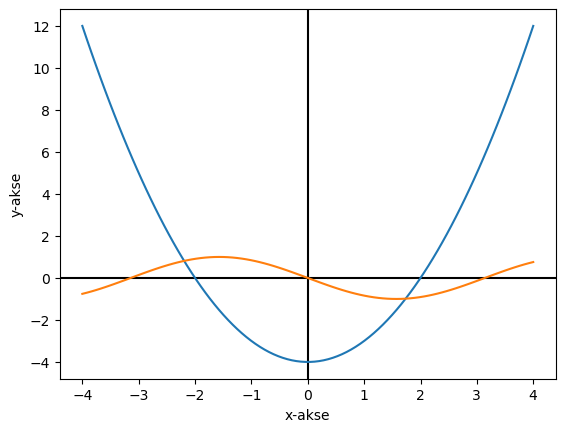

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# definerer funksjonene
def f(x):
    return x**2-4

def g(x):
    return -np.sin(x)

# Lager x-verditabell
x = np.linspace(-4, 4, 100)

# Plotter y mot x og setter på aksenavn
plt.xlabel("x-akse")
plt.ylabel("y-akse")
plt.axvline(x=0, color="black") # tegner x-aksen i svart
plt.axhline(y=0, color="black") # Tegner y-aksen i svart
# siden funksjonen returnerer y-tabell kan jeg bruke funksjonskallet direkte i plot()
plt.plot(x,f(x))
plt.plot(x,g(x))
plt.show()